In [1]:
from src.DataFolder import DataFolder
from src.ThetaSignal import ThetaSignal
from src.pipeline import emd_analysis

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data_path = "/home/miranjo/phasic_tonic/data/processed"
config_path = "/home/miranjo/phasic_tonic/configs/test.yaml"

## Setup

### Load the config file

In [2]:
with open(config_path, 'r') as f:
    args = yaml.safe_load(f)

fs                  = args.pop("fs")
f_theta             = (args.pop("f_theta_lower"), args.pop("f_theta_upper"))
f_lowpass           = args.pop("f_lowpass")
n_seconds_filter    = args.pop("n_seconds_filter")
n_seconds_theta     = args.pop("n_seconds_theta")
threshold_kwargs    = args.pop("threshold_kwargs")
skip_threshold      = args.pop("skip_threshold")

### Load the dataset

In [3]:
remFolder = DataFolder(data_path)
print(remFolder)

DataFolder in '/home/miranjo/phasic_tonic/data/processed', contains 102 files.


In [50]:
def metaname(metadata):
    name = metadata["RatID"] + "_" + metadata["StudyDay"] + "_" + metadata["condition_full"] + "_"
    if metadata["treatment"] == "TreatmentPositive":
        name += "CBD"
    else:
        name += "VEH"
    name += "_" + metadata["posstrial_number"]
    return name

def plot_signal(thetaSignal, metadata, xlim=None, ylim=None):
    fig, ax = plt.subplots(figsize=(16, 4))
    times = np.arange(0, thetaSignal.duration, 1 / thetaSignal.sampling_rate)

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Voltage (uV)')

    ax.plot(times, thetaSignal.raw_signal, color='k', label='raw')

    if thetaSignal.filtered is not None:
        ax.plot(times, thetaSignal.filtered, label=thetaSignal.filter_type, color='r')
        ax.legend()
        
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_title(metaname(metadata))

# Analysis

## Sample

Some signals have sudden jumps

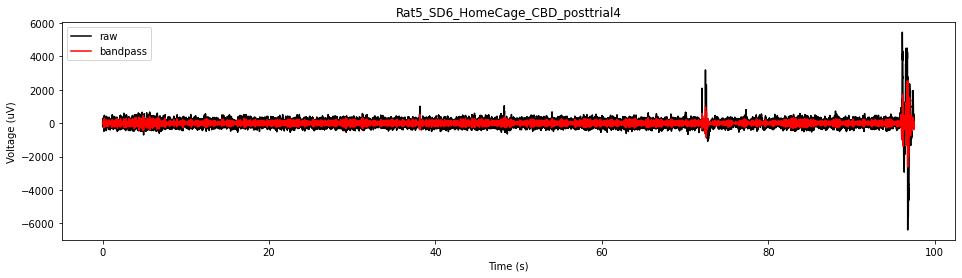

In [61]:
remData = remFolder[2]
arrays = remData["data"]
metadata = remData["metadata"]

sig = ThetaSignal(arrays[0], fs)
sig.filter("bandpass", f_theta, n_seconds_theta)
plot_signal(sig, metadata)

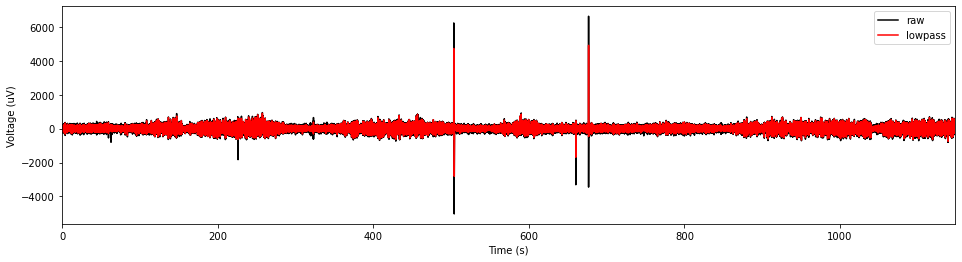

In [23]:
remData = remFolder[6]
arrays = remData["data"]
metadata = remData["metadata"]

sig = ThetaSignal(arrays[0], fs)
sig.filter('lowpass', f_lowpass, n_seconds_filter)
sig.plot()

Too short recordings

(611,)


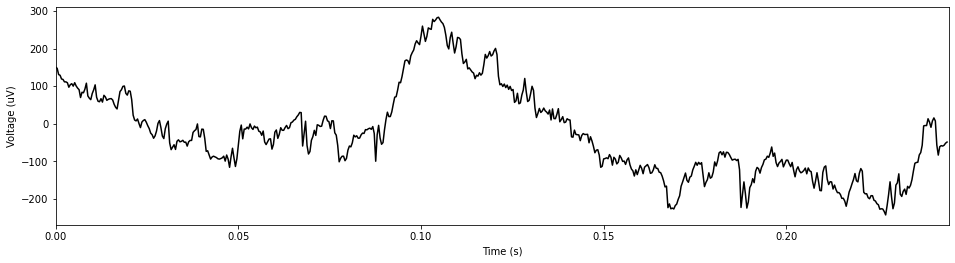

In [84]:
remData = remFolder[1]
array = remData["data"][15]
metadata = remData["metadata"]

print(array.shape)
sig = ThetaSignal(array, fs)
sig.plot()

(1043,)


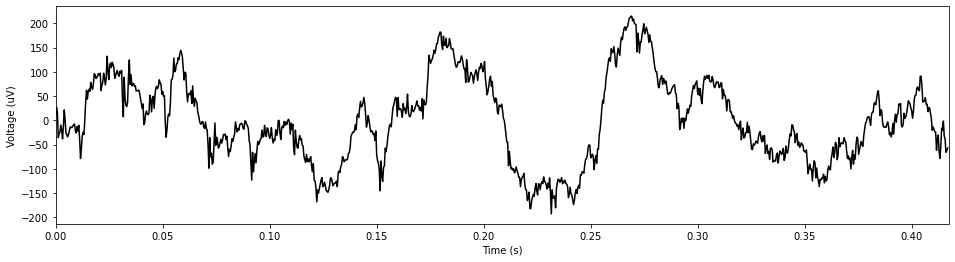

In [85]:
remData = remFolder[6]
array = remData["data"][12]
metadata = remData["metadata"]

print(array.shape)
sig = ThetaSignal(array, fs)
sig.plot()

In [83]:
sig.summary()

Sampling rate: 2500 Hz
Duration: 0.42 seconds
Max value: 214.72 uV
Min value: -193.21 uV
Mean value: 0.31 uV
Standard Deviation: 85.66 uV
Signal Range: 407.92 uV
Number of Data Points: 1043


In [13]:
metadata

{'RatID': 'Rat4',
 'StudyDay': 'SD9',
 'condition': 'HC',
 'condition_full': 'HomeCage',
 'treatment': 'TreatmentNegative',
 'posstrial_number': 'posttrial3'}

## Dataset

In [92]:
durations = {}

for i, sample in enumerate(remFolder):
    lfpREMs = sample["data"]
    metadata = sample["metadata"]
    name = metaname(metadata)

    for j, lfpREM in enumerate(lfpREMs):
        theta = ThetaSignal(lfpREM, fs)
        durations[name + "_" + str(i) + "_" + str(j)] = theta.duration
        print(str(i) + ":" + str(j))


0:0
0:1
1:0
1:1
1:2
1:3
1:4
1:5
1:6
1:7
1:8
1:9
1:10
1:11
1:12
1:13
1:14
1:15
1:16
1:17
1:18
1:19
1:20
1:21
1:22
2:0
2:1
2:2
3:0
4:0
5:0
5:1
5:2
5:3
5:4
5:5
5:6
5:7
5:8
5:9
5:10
5:11
5:12
5:13
5:14
5:15
5:16
6:0
6:1
6:2
6:3
6:4
6:5
6:6
6:7
6:8
6:9
6:10
6:11
6:12
6:13
6:14
6:15
6:16
6:17
6:18
6:19
6:20
7:0
7:1
7:2
7:3
7:4
7:5
7:6
7:7
8:0
8:1
8:2
8:3
8:4
8:5
8:6
8:7
8:8
8:9
8:10
8:11
8:12
9:0
10:0
10:1
10:2
10:3
10:4
10:5
10:6
10:7
10:8
10:9
10:10
10:11
10:12
11:0
11:1
11:2
11:3
11:4
12:0
12:1
12:2
13:0
13:1
13:2
13:3
14:0
14:1
14:2
14:3
14:4
15:0
15:1
15:2
15:3
16:0
16:1
16:2
16:3
16:4
16:5
16:6
16:7
16:8
16:9
16:10
16:11
16:12
16:13
16:14
16:15
16:16
16:17
17:0
17:1
17:2
18:0
18:1
18:2
18:3
18:4
18:5
18:6
18:7
19:0
19:1
20:0
20:1
20:2
20:3
21:0
21:1
22:0
23:0
24:0
24:1
24:2
24:3
24:4
25:0
25:1
26:0
27:0
27:1
27:2
28:0
28:1
28:2
28:3
28:4
28:5
28:6
28:7
28:8
28:9
28:10
28:11
29:0
29:1
30:0
31:0
31:1
31:2
31:3
31:4
31:5
31:6
31:7
31:8
31:9
31:10
31:11
31:12
31:13
32:0
32:1
32:2
32:3
33:0

In [102]:
df = pd.DataFrame({"names":[key for key in durations], "durations":[durations[key] for key in durations]})
df

,names,durations
0,Rat5_SD5_ObjectSpace_CBD_posttrial4_0_0,83.8396
1,Rat5_SD5_ObjectSpace_CBD_posttrial4_0_1,111.4648
2,Rat3_SD6_ObjectSpace_CBD_posttrial5_1_0,154.8600
3,Rat3_SD6_ObjectSpace_CBD_posttrial5_1_1,40.9892
4,Rat3_SD6_ObjectSpace_CBD_posttrial5_1_2,104.9600
...,...,...
541,Rat5_SD17_HomeCage_CBD_posttrial5_101_4,43.1476
542,Rat5_SD17_HomeCage_CBD_posttrial5_101_5,34.6904
543,Rat5_SD17_HomeCage_CBD_posttrial5_101_6,0.0000
544,Rat5_SD17_HomeCage_CBD_posttrial5_101_7,103.4284


In [105]:
df[df["durations"]<0.5]

,names,durations
17,Rat3_SD6_ObjectSpace_CBD_posttrial5_1_15,0.2444
59,Rat3_SD4_ObjectSpace_VEH_posttrial5_6_12,0.4172
94,Rat3_SD17_HomeCage_VEH_posttrial5_10_4,0.3156
101,Rat3_SD17_HomeCage_VEH_posttrial5_10_11,0.0300
104,Rat5_SD7_HomeCage_CBD_posttrial2_11_1,0.0128
395,Rat5_SD3_ObjectSpace_VEH_posttrial4_72_1,0.1648
399,Rat5_SD3_ObjectSpace_VEH_posttrial4_72_5,0.3516
441,Rat4_SD7_HomeCage_CBD_posttrial5_77_9,0.0200
449,Rat4_SD6_ObjectSpace_VEH_posttrial4_80_3,0.0000
470,Rat5_SD14_ObjectSpace_VEH_posttrial2_86_1,0.0000


In [100]:
durations

{'Rat5_SD5_ObjectSpace_CBD_posttrial4_0_0': 83.8396,
 'Rat5_SD5_ObjectSpace_CBD_posttrial4_0_1': 111.4648,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_0': 154.86,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_1': 40.9892,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_2': 104.96,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_3': 105.6272,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_4': 130.0748,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_5': 34.6088,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_6': 163.0608,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_7': 155.3444,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_8': 18.966,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_9': 13.9768,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_10': 122.128,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_11': 12.836,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_12': 9.49,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_13': 110.8416,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_14': 94.4488,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_15': 0.2444,
 'Rat3_SD6_ObjectSpace_CBD_posttrial5_1_16